In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
#dataset loaded
df=pd.read_csv('Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [5]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [6]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
#separating independent & dependent variables
X=df.iloc[:, :-1].values
y=df.iloc[:, -1].values

In [8]:
#splitting train & test data
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
#scaling features
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [10]:
#training model
regr=GaussianNB()
regr.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


In [11]:
#prediction 
y_pred=regr.predict(X_test_scaled)
print(y_pred)

[1 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0 0 1 0 0 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0
 0 0 1 1 0 0]


In [12]:
proba=regr.predict_proba(X_test_scaled)
print(proba)

[[0.49227308 0.50772692]
 [0.0307671  0.9692329 ]
 [0.96668845 0.03331155]
 [0.18717954 0.81282046]
 [0.95463821 0.04536179]
 [0.94938333 0.05061667]
 [0.12697738 0.87302262]
 [0.92283812 0.07716188]
 [0.72165421 0.27834579]
 [0.69995022 0.30004978]
 [0.88866879 0.11133121]
 [0.22511541 0.77488459]
 [0.98322347 0.01677653]
 [0.98488691 0.01511309]
 [0.89674672 0.10325328]
 [0.5487331  0.4512669 ]
 [0.27301897 0.72698103]
 [0.46407705 0.53592295]
 [0.82879706 0.17120294]
 [0.12769202 0.87230798]
 [0.98220364 0.01779636]
 [0.93064403 0.06935597]
 [0.44944676 0.55055324]
 [0.04818732 0.95181268]
 [0.98512913 0.01487087]
 [0.26514243 0.73485757]
 [0.60288476 0.39711524]
 [0.87078588 0.12921412]
 [0.00692648 0.99307352]
 [0.98592957 0.01407043]
 [0.56621352 0.43378648]
 [0.98628317 0.01371683]
 [0.0437974  0.9562026 ]
 [0.94166909 0.05833091]
 [0.35361955 0.64638045]
 [0.86030729 0.13969271]
 [0.86882576 0.13117424]
 [0.8272453  0.1727547 ]
 [0.97128905 0.02871095]
 [0.98841847 0.01158153]


In [13]:
accuracy=accuracy_score(y_test, y_pred)
accuracy

0.9375

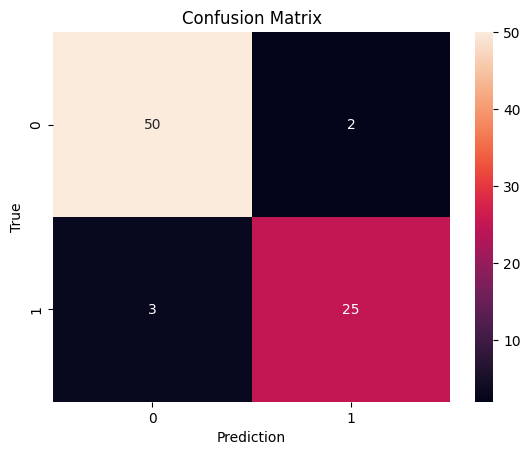

In [14]:
confusion=confusion_matrix(y_test, y_pred)
sns.heatmap(confusion, annot=True)
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('naive_bayes_conf_matrix.png')
plt.show()

In [15]:
regr.predict([[27, 80000]])

array([1])

In [17]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train_scaled), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, regr.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Naive Bayes (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.savefig('model_pred-plot.png')
plt.show()

MemoryError: Unable to allocate 2.03 GiB for an array with shape (135904000, 2) and data type float64